In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi

# =========================
# Two-body decay generator
# =========================

def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df   

# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937,
    "Phi" : 1.02
}


# =========================
# Generate datasets
# =========================

N = 10000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

#Phi decays
df_list.append(two_body_decay(N, masses["Phi"], masses["K"], masses["K"], "Phi→KK"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))


df_list[0]


,process,E1,px1,py1,pz1,E2,px2,py2,pz2
0,Jpsi→pp,1.54845,-0.076278,-1.075948,0.595291,1.54845,0.076278,1.075948,-0.595291
1,Jpsi→pp,1.54845,0.460822,-0.877798,-0.731415,1.54845,-0.460822,0.877798,0.731415
2,Jpsi→pp,1.54845,0.726472,0.600576,0.793347,1.54845,-0.726472,-0.600576,-0.793347
3,Jpsi→pp,1.54845,-0.301294,-1.111909,-0.436732,1.54845,0.301294,1.111909,0.436732
4,Jpsi→pp,1.54845,-1.230266,0.038383,-0.053169,1.54845,1.230266,-0.038383,0.053169
...,...,...,...,...,...,...,...,...,...
9995,Jpsi→pp,1.54845,0.617273,1.062985,0.083013,1.54845,-0.617273,-1.062985,-0.083013
9996,Jpsi→pp,1.54845,0.977806,-0.742742,0.100413,1.54845,-0.977806,0.742742,-0.100413
9997,Jpsi→pp,1.54845,-0.448173,-0.380137,-1.082816,1.54845,0.448173,0.380137,1.082816
9998,Jpsi→pp,1.54845,0.872501,0.005586,-0.869807,1.54845,-0.872501,-0.005586,0.869807


# Smearing section and energy recomputing


In [106]:
#Smearing
def smear_momentum(df, sigma_rel=0.01):
    for comp in ["px1", "py1", "pz1", "px2", "py2", "pz2"]:
        sigma = sigma_rel * np.abs(df[comp])
        df[comp] = np.random.normal(df[comp], sigma)

    return df

df = pd.concat(df_list, ignore_index=True)

mass_map = {
    "Jpsi→pp": (masses["p"], masses["p"]),
    "Jpsi→mumu": (masses["mu"], masses["mu"]),
    "Jpsi→ee": (masses["e"], masses["e"]),
    "Psip→mumu": (masses["mu"], masses["mu"]),
    "Phi→KK": (masses["K"], masses["K"]),
    "γγ→mumu": (masses["mu"], masses["mu"]),
    "γγ→ee": (masses["e"], masses["e"]),
    "γγ→KK": (masses["K"], masses["K"]),
}
df["p1"] = np.sqrt(df["px1"]**2 + df["py1"]**2 + df["pz1"]**2)
df["p2"] = np.sqrt(df["px2"]**2 + df["py2"]**2 + df["pz2"]**2)

# Apply smearing
df = smear_momentum(df, sigma_rel=0.02)  # 2% resolution

def recompute_all_energies(df):
    for proc, (m1, m2) in mass_map.items():
        mask = df["process"] == proc

        p1_sq = df.loc[mask, ["px1","py1","pz1"]].pow(2).sum(axis=1)
        p2_sq = df.loc[mask, ["px2","py2","pz2"]].pow(2).sum(axis=1)

        df.loc[mask, "E1"] = np.sqrt(p1_sq + m1**2)
        df.loc[mask, "E2"] = np.sqrt(p2_sq + m2**2)

    return df



df_before = df.copy()

df_after = smear_momentum(df.copy(), sigma_rel= 0.04)
df_after = recompute_all_energies(df_after)

# Momentum comparisons

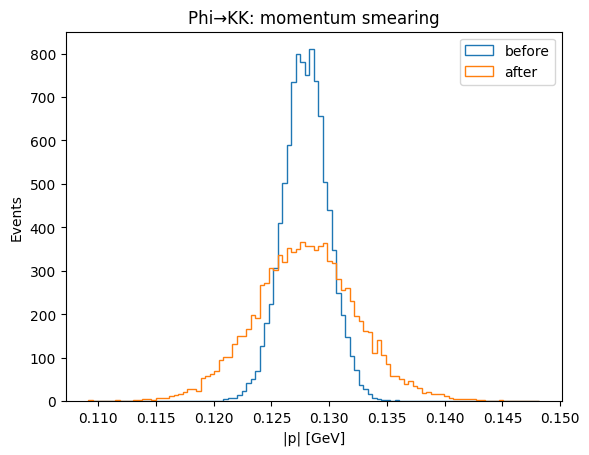

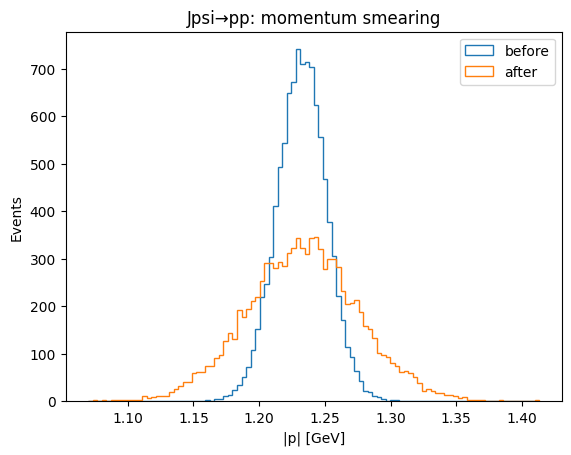

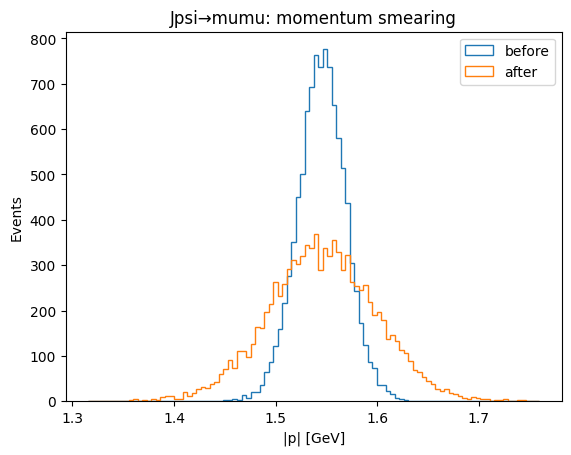

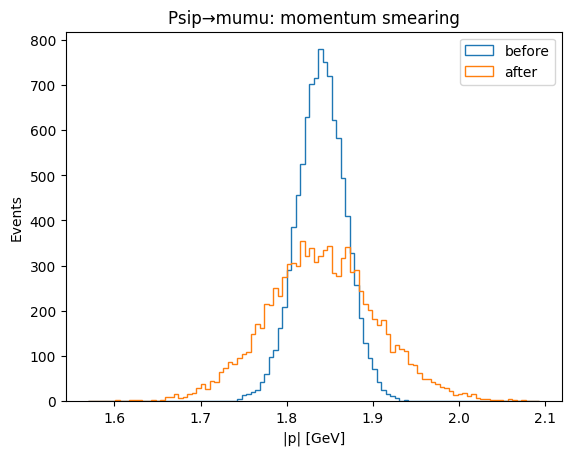

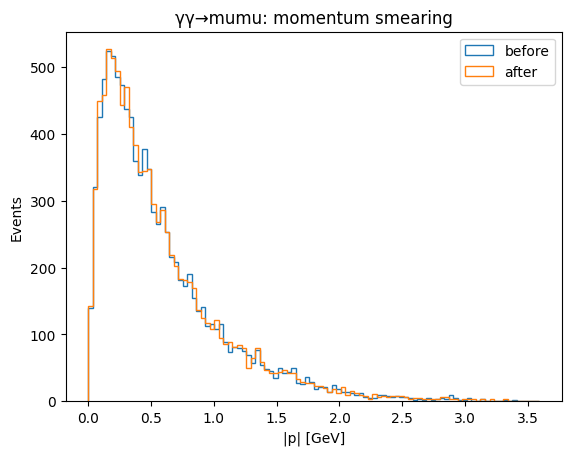

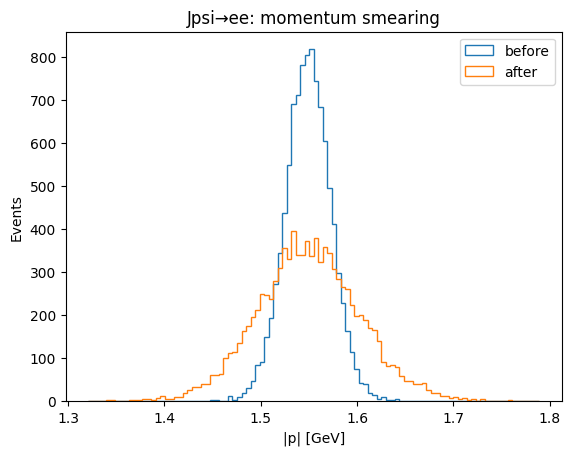

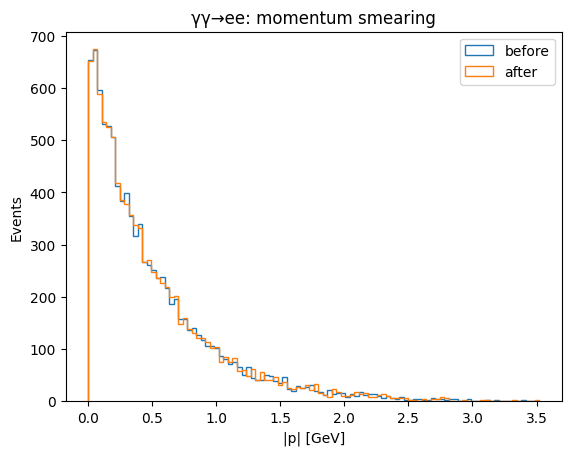

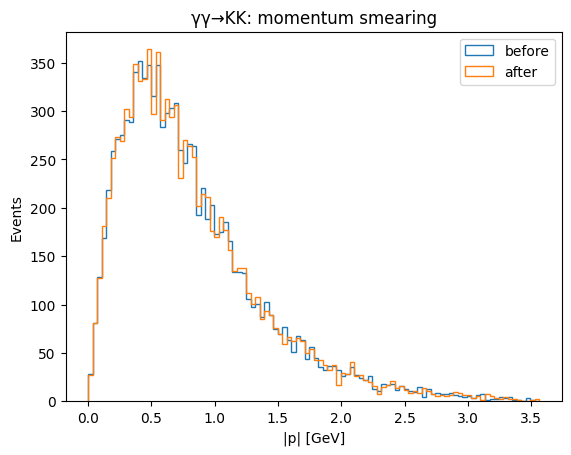

In [107]:
def plot_momentum_comparison(df_before, df_after, process):

    b = df_before[df_before["process"] == process]
    a = df_after[df_after["process"] == process]

    # compute |p|
    p1_b = np.sqrt(b["px1"]**2 + b["py1"]**2 + b["pz1"]**2)
    p1_a = np.sqrt(a["px1"]**2 + a["py1"]**2 + a["pz1"]**2)

    # clean
    p1_b = p1_b.replace([np.inf, -np.inf], np.nan).dropna()
    p1_a = p1_a.replace([np.inf, -np.inf], np.nan).dropna()

    if len(p1_b) == 0 or len(p1_a) == 0:
        print(f"{process}: no data")
        return

    # check spread
    pmin = min(p1_b.min(), p1_a.min())
    pmax = max(p1_b.max(), p1_a.max())

    if np.isclose(pmin, pmax):
        # ultra-narrow → use fixed small window
        center = pmin
        width = 0.01  # GeV (tune if needed)
        bins = 30
        hist_range = (center - width, center + width)
    else:
        bins = min(100, int(np.sqrt(len(p1_b))))
        hist_range = (pmin, pmax)

    plt.hist(p1_b, bins=bins, range=hist_range, histtype="step", label="before")
    plt.hist(p1_a, bins=bins, range=hist_range, histtype="step", label="after")

    plt.xlabel("|p| [GeV]")
    plt.ylabel("Events")
    plt.title(f"{process}: momentum smearing")
    plt.legend()
    plt.show()

plot_momentum_comparison(df_before, df_after, "Phi→KK")
plot_momentum_comparison(df_before, df_after, "Jpsi→pp")
plot_momentum_comparison(df_before, df_after, "Jpsi→mumu")
plot_momentum_comparison(df_before, df_after, "Psip→mumu")
plot_momentum_comparison(df_before, df_after, "γγ→mumu")
plot_momentum_comparison(df_before, df_after, "Jpsi→ee")
plot_momentum_comparison(df_before, df_after, "γγ→ee")
plot_momentum_comparison(df_before, df_after, "γγ→KK")

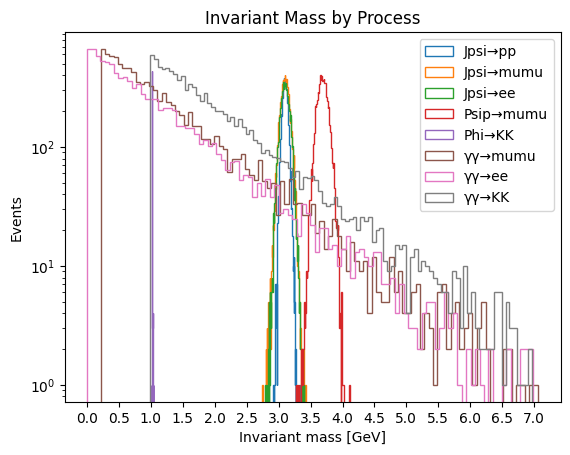

In [108]:
m2 = (
    (df_after["E1"] + df_after["E2"])**2
    - (df_after["px1"] + df_after["px2"])**2
    - (df_after["py1"] + df_after["py2"])**2
    - (df_after["pz1"] + df_after["pz2"])**2
)

df_after["m_inv"] = np.sqrt(np.maximum(m2, 0))

for proc in df_after["process"].unique():
    subset = df_after[df_after["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()

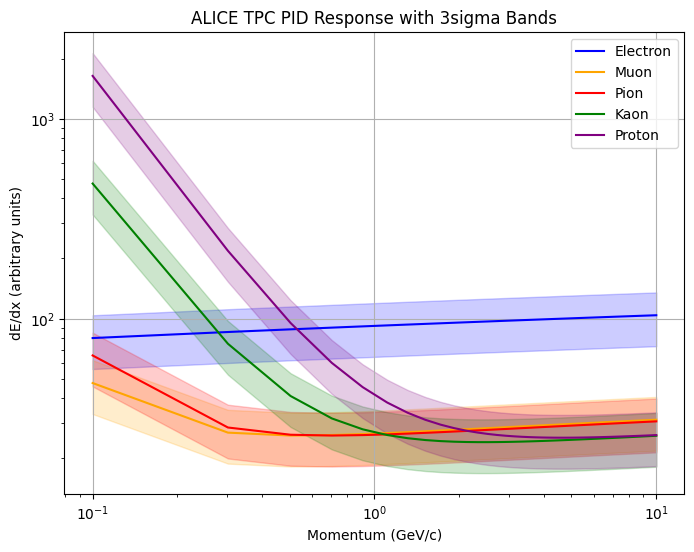

In [109]:
def bethe_bloch(momentum, mass, charge=1):
# Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

# Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

# Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx

    # Example usage
    momentum = .3 # Example momentum in GeV/c
    particle_type = 'proton' # Example particle type
    x=1000 #Amount of random numbers

    rn=[]
    for _ in range(x):

        if (particle_type == 'electron'):
            stretch_factor=1
        elif (particle_type == 'muon'):
            stretch_factor=.41
        elif (particle_type == 'pion'):
            stretch_factor=.41
        elif (particle_type == 'kaon'):
            stretch_factor=.38
        elif (particle_type == 'proton'):
            stretch_factor=.40

    random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
    rn.append(random_value)

    print(rn)

    xvalues=[]
    for _ in range(x):
        xvalues.append(momentum)
    print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
    'Electron': {'color': 'blue', 'stretch_factor': 1},
    'Muon': {'color': 'orange', 'stretch_factor': 0.41},
    'Pion': {'color': 'red', 'stretch_factor': 0.41},
    'Kaon': {'color': 'green', 'stretch_factor': 0.38},
    'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)


# plt.plot(xvalues,rn, color= 'black')
momentum_range = np.linspace(0.1, 10) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')  # Log scale for x-axis
plt.yscale('log')  # Log scale for y-axis
plt.title('ALICE TPC PID Response with 3sigma Bands')
plt.legend()
plt.grid(True)
plt.show()


#Generate a momentum range and plot




NameError: name 'process_colors' is not defined

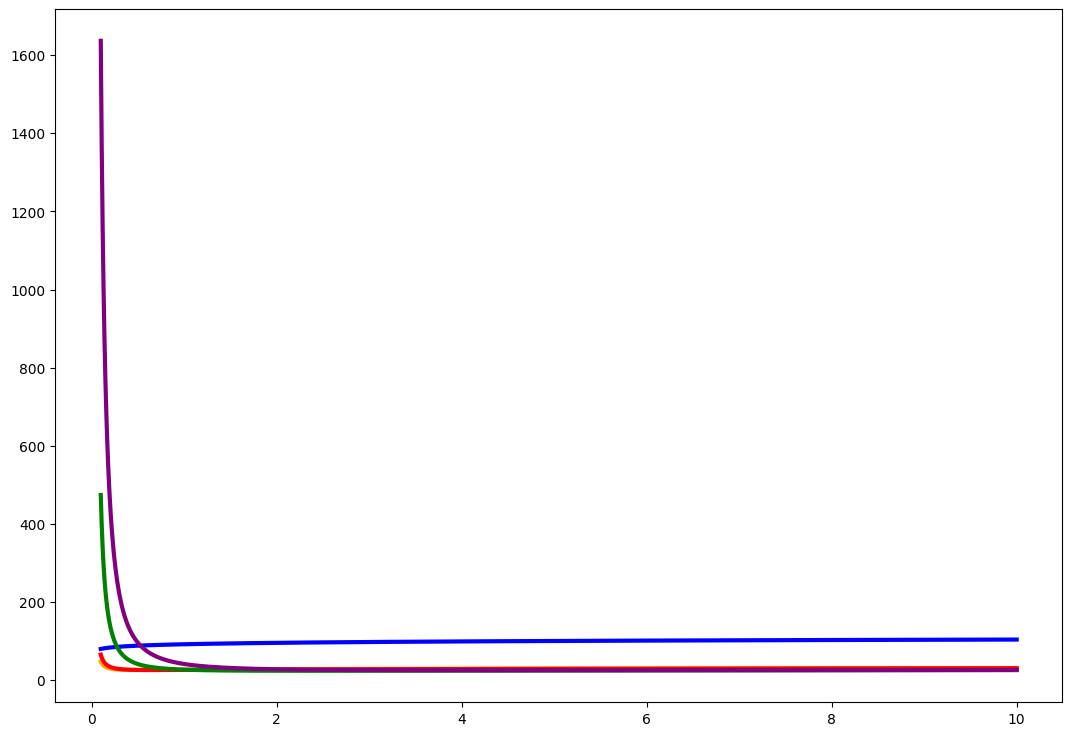

In [ ]:


# =========================================================
# PID IDENTIFICATION
# =========================================================

def identify_particle(momentum, measured_dEdx, sigma):

    chi2_results = {}

    for particle in mass_dict.keys():

        mass = mass_dict[particle]
        stretch = stretch_dict[particle]

        expected = (
            bethe_bloch(momentum, mass)
            * stretch
        )

        chi2 = ((measured_dEdx - expected) / sigma)**2

        chi2_results[particle] = chi2

    best_particle = min(
        chi2_results,
        key=chi2_results.get
    )

    return best_particle, chi2_results


# =========================================================
# APPLY TPC PID TO GENERATED TRACKS
# =========================================================

# Create containers
dedx1 = []
dedx2 = []

sigma1 = []
sigma2 = []

pid1 = []
pid2 = []

# Loop over all events
for idx, row in df_after.iterrows():

    process = row["process"]

    true_particle = process_to_particle[process]

    # -----------------------------------
    # Track 1
    # -----------------------------------

    p1 = row["p1"]

    d1, s1 = generate_tpc_signal(
        p1,
        true_particle
    )

    identified1, chi21 = identify_particle(
        p1,
        d1,
        s1
    )

    dedx1.append(d1)
    sigma1.append(s1)
    pid1.append(identified1)

    # -----------------------------------
    # Track 2
    # -----------------------------------

    p2 = row["p2"]

    d2, s2 = generate_tpc_signal(
        p2,
        true_particle
    )

    identified2, chi22 = identify_particle(
        p2,
        d2,
        s2
    )

    dedx2.append(d2)
    sigma2.append(s2)
    pid2.append(identified2)


# =========================================================
# STORE RESULTS
# =========================================================

df_after["TPC_dEdx_1"] = dedx1
df_after["TPC_dEdx_2"] = dedx2

df_after["TPC_sigma_1"] = sigma1
df_after["TPC_sigma_2"] = sigma2

df_after["PID_1"] = pid1
df_after["PID_2"] = pid2


# =========================================================
# DISPLAY SAMPLE RESULTS
# =========================================================

print(df_after[
    [
        "process",
        "p1",
        "TPC_dEdx_1",
        "PID_1",
        "p2",
        "TPC_dEdx_2",
        "PID_2"
    ]
].head(20))


# =========================================================
# PLOT TPC RESPONSE
# =========================================================

momentum_range = np.linspace(0.1, 10, 1000)

colors = {
    'electron': 'blue',
    'muon': 'orange',
    'pion': 'red',
    'kaon': 'green',
    'proton': 'purple'
}

plt.figure(figsize=(12,8))

# -----------------------------------
# Bethe-Bloch curves
# -----------------------------------

for particle in mass_dict.keys():

    mass = mass_dict[particle]
    stretch = stretch_dict[particle]

    curve = (
        bethe_bloch(momentum_range, mass)
        * stretch
    )

    plt.plot(
        momentum_range,
        curve,
        color=colors[particle],
        linewidth=2,
        label=particle
    )


# -----------------------------------
# Track 1 points
# -----------------------------------

for particle in mass_dict.keys():

    mask = df_after["PID_1"] == particle

    plt.scatter(
        df_after.loc[mask, "p1"],
        df_after.loc[mask, "TPC_dEdx_1"],
        s=5,
        alpha=0.4,
        color=colors[particle]
    )


# -----------------------------------
# Log scales
# -----------------------------------

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Momentum (GeV/c)", fontsize=14)
plt.ylabel("TPC dE/dx", fontsize=14)

plt.title(
    "Simulated ALICE TPC PID Response",
    fontsize=16
)

plt.grid(True)
plt.legend()

plt.show()


# =========================================================
# PID CONFUSION SUMMARY
# =========================================================

true_labels = []
reco_labels = []

for idx, row in df_after.iterrows():

    true_particle = process_to_particle[row["process"]]

    true_labels.append(true_particle)
    reco_labels.append(row["PID_1"])

summary = pd.crosstab(
    pd.Series(true_labels, name="True"),
    pd.Series(reco_labels, name="Identified")
)

print("\nPID CONFUSION MATRIX\n")
print(summary)